# Data Dictionary

All datasets are aggregated per user per month. `userMonth` is the number of calendar months since the user's first action on Community Notes. Together the datasets contain the full trajectories for a sample of 20,000 users.

## Notes (`sample_user_note_traj.parquet`)

- `noteAuthorParticipantId` — User identifier
- `userMonth` — Calendar months since user's first action
- `calendarMonth` — Calendar month of activity (YYYY-MM)
- `notesCreated` — Number of notes written by user
- `hits` — Number of user's notes that achieved CRH (Currently Rated Helpful) status
- `hitRate` — Fraction of user's notes that achieved CRH status
- `avgNoteFactor` — Mean note factor of notes user wrote
- `avgNoteIntercept` — Mean note intercept of notes user wrote
- `topicsTargeted` — Number of distinct topics targeted
- `avgRatingsEarned` — Mean number of community ratings received per note
- `{topic}Count` — Notes written on each topic. Topics: `sports`, `diaries_&_daily_life`, `business_&_entrepreneurs`, `science_&_technology`, `news_&_social_concern`, `other`

## Ratings (`sample_user_rating_traj.parquet`)

- `raterParticipantId` — User identifier
- `userMonth` — Calendar months since user's first action
- `calendarMonth` — Calendar month of activity (YYYY-MM)
- `notesRated` — Total number of notes rated
- `avgHelpfulFactor`, `avgNotHelpfulFactor`, `helpfulNotHelpfulFactorDiff` — Mean note factor of notes the user rated helpful vs. not helpful
- `avgHelpfulIntercept`, `avgNotHelpfulIntercept`, `helpfulNotHelpfulInterceptDiff` — Mean note intercept of notes the user rated helpful vs. not helpful
- `correctHelpfuls` — Number of helpful ratings on notes that achieved CRH status
- `correctNotHelpfuls` — Number of non-helpful ratings on notes that did not achieve CRH status
- `overallAccuracy` — `(correctHelpfuls + correctNotHelpfuls) / notesRated`
- `posFactorRatedHelpful`, `posFactorRatedNotHelpful`, `negFactorRatedHelpful`, `negFactorRatedNotHelpful` — Count of ratings split by note factor sign (+/-) and whether the user rated it helpful or not
- `pctCorrectPosFactorHelpful`, `pctCorrectPosFactorNotHelpful`, `pctCorrectNegFactorHelpful`, `pctCorrectNegFactorNotHelpful` — Fraction correct within each factor-sign x helpfulness bucket
- `pctHelpfulRatingsCorrect` — Fraction of helpful ratings where the note achieved CRH
- `pctNotHelpfulRatingsCorrect` — Fraction of non-helpful ratings where the note did not achieve CRH
- `uniqueDaysRated` — Number of distinct days the user rated notes
- `avgPostsRatedPerDay` — `notesRated / uniqueDaysRated`
- `uniqueTopicsRated` — Number of distinct topics rated
- `{anti,pro}{Dem,Rep}{NN,NNN}Ratings` — Partisan rating classifications from Nudo et al. `anti`/`pro` = rating direction, `Dem`/`Rep` = post author party, `NN` = note claims misinformation, `NNN` = note claims not misinformation. 8 columns total
- `proDemRatings`, `antiDemRatings`, `proRepRatings`, `antiRepRatings` — Summed partisan totals across NN and NNN variants
- `{topic}RatedCount` — Notes rated per topic. Same 6 topics as the notes dataset

## Requests (`sample_user_request_traj.parquet`)

- `requesterParticipantId` — User identifier
- `userMonth` — Calendar months since user's first action
- `calendarMonth` — Calendar month of activity (YYYY-MM)
- `requestsMade` — Number of note requests submitted
- `numRequestsResultingInNote` — Requests where at least one note was written
- `numRequestsResultingInCrh` — Requests where at least one note achieved CRH status
- `pctRequestResultedInNote` — Fraction of requests resulting in a note
- `pctRequestResultedInCrh` — Fraction of requests resulting in a CRH note


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.dates as mdates

In [109]:
note = pd.read_parquet("data/sample_user_note_traj.parquet")
ratings = pd.read_parquet("data/sample_user_rating_traj.parquet")
request = pd.read_parquet("data/sample_user_request_traj.parquet")

#### For raters, consider the average note factor of notes they rate helpful and not helpful, along with how many notes with positive/negative factors they rated helpful/not helpful?

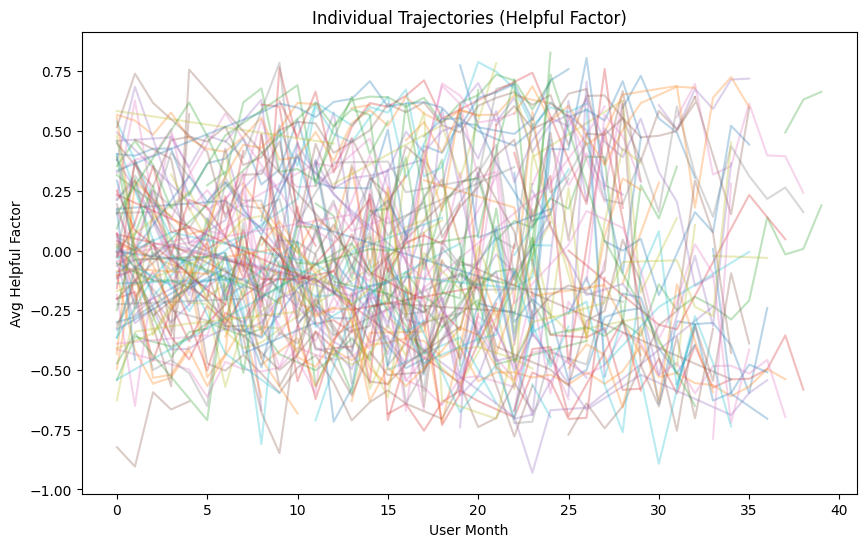

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

user_counts = ratings.groupby("raterParticipantId")["userMonth"].count()
eligible = user_counts[user_counts >= 10].index
sampled = np.random.default_rng(42).choice(eligible, size=min(100, len(eligible)), replace=False)
sample_df = ratings[ratings["raterParticipantId"].isin(sampled)]


plt.figure(figsize=(10,6))

for uid, g in sample_df.groupby("raterParticipantId"):
    plt.plot(g["userMonth"], g["avgHelpfulFactor"], alpha=0.3)

plt.xlabel("User Month")
plt.ylabel("Avg Helpful Factor")
plt.title("Individual Trajectories (Helpful Factor)")
plt.show()


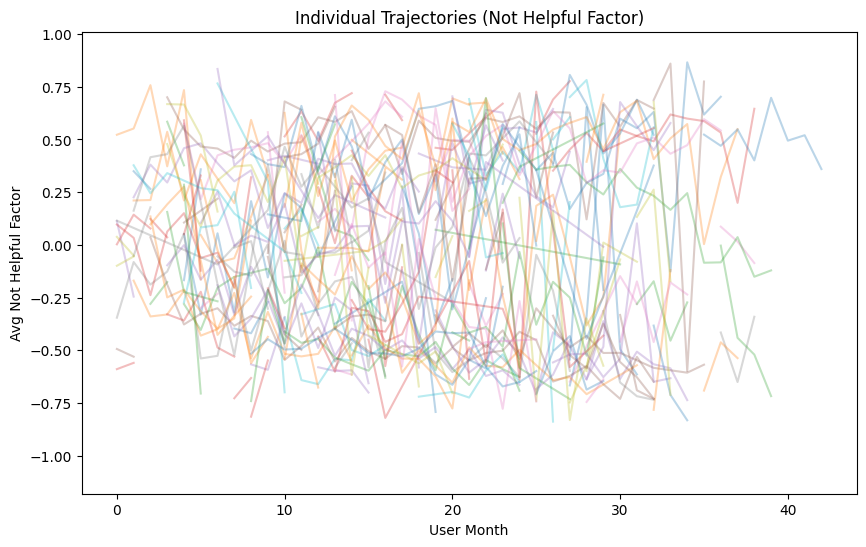

In [94]:
plt.figure(figsize=(10,6))

for uid, g in sample_df.groupby("raterParticipantId"):
    plt.plot(g["userMonth"], g["avgNotHelpfulFactor"], alpha=0.3)

plt.xlabel("User Month")
plt.ylabel("Avg Not Helpful Factor")
plt.title("Individual Trajectories (Not Helpful Factor)")
plt.show()

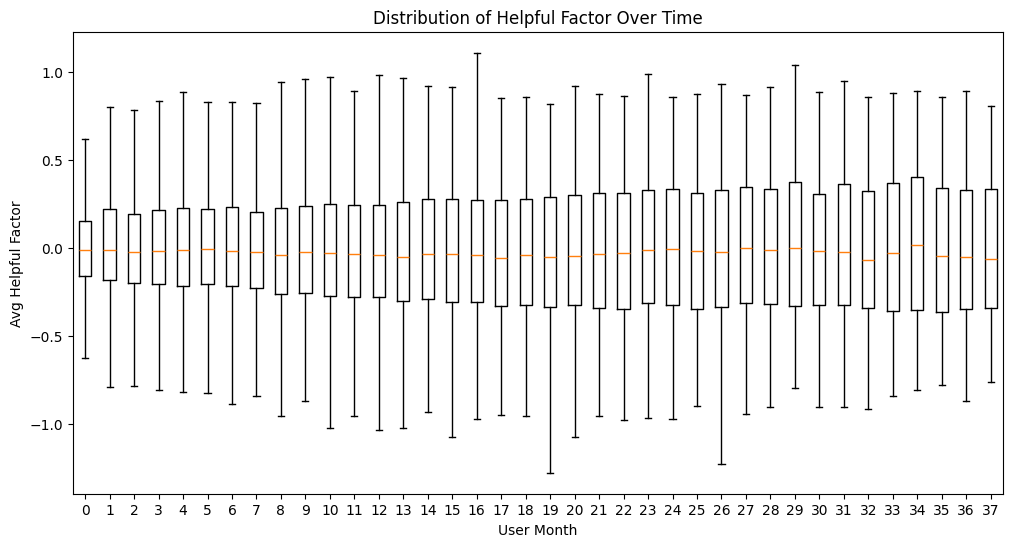

In [111]:
# Keep months with enough data
month_counts = ratings["userMonth"].value_counts()
valid_months = month_counts[month_counts > 200].index

plot_df = ratings[ratings["userMonth"].isin(valid_months)]

# Sort months
months_sorted = sorted(valid_months)

data = [plot_df[plot_df["userMonth"] == m]["avgHelpfulFactor"].dropna()
        for m in months_sorted]

plt.figure(figsize=(12,6))
plt.boxplot(data, positions=months_sorted, showfliers=False)

plt.xlabel("User Month")
plt.ylabel("Avg Helpful Factor")
plt.title("Distribution of Helpful Factor Over Time")
plt.show()

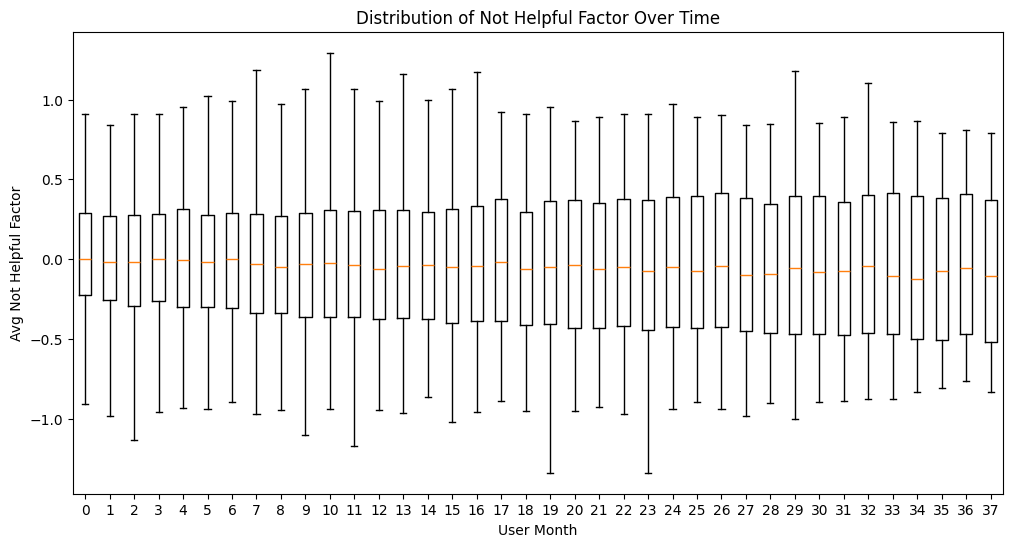

In [98]:
# Keep months with enough data
month_counts = ratings["userMonth"].value_counts()
valid_months = month_counts[month_counts > 200].index

plot_df = ratings[ratings["userMonth"].isin(valid_months)]

# Sort months
months_sorted = sorted(valid_months)

data = [plot_df[plot_df["userMonth"] == m]["avgNotHelpfulFactor"].dropna()
        for m in months_sorted]

plt.figure(figsize=(12,6))
plt.boxplot(data, positions=months_sorted, showfliers=False)

plt.xlabel("User Month")
plt.ylabel("Avg Not Helpful Factor")
plt.title("Distribution of Not Helpful Factor Over Time")
plt.show()

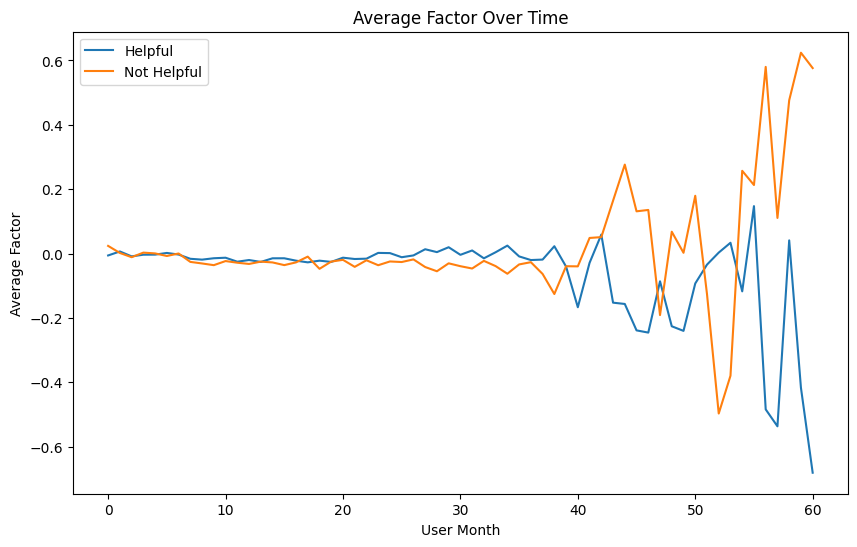

In [112]:
# Avoid division by zero
eps = 1e-9

ratings["totalPos"] = ratings["posFactorRatedHelpful"] + ratings["posFactorRatedNotHelpful"]
ratings["totalNeg"] = ratings["negFactorRatedHelpful"] + ratings["negFactorRatedNotHelpful"]

ratings["frac_pos_helpful"] = ratings["posFactorRatedHelpful"] / (ratings["totalPos"] + eps)
ratings["frac_neg_helpful"] = ratings["negFactorRatedHelpful"] / (ratings["totalNeg"] + eps)

agg = ratings.groupby("userMonth").agg({
    "avgHelpfulFactor": "mean",
    "avgNotHelpfulFactor": "mean",
    "frac_pos_helpful": "mean",
    "frac_neg_helpful": "mean"
}).reset_index()

plt.figure(figsize=(10,6))

plt.plot(agg["userMonth"], agg["avgHelpfulFactor"], label="Helpful")
plt.plot(agg["userMonth"], agg["avgNotHelpfulFactor"], label="Not Helpful")

plt.xlabel("User Month")
plt.ylabel("Average Factor")
plt.title("Average Factor Over Time")
plt.legend()
plt.show()

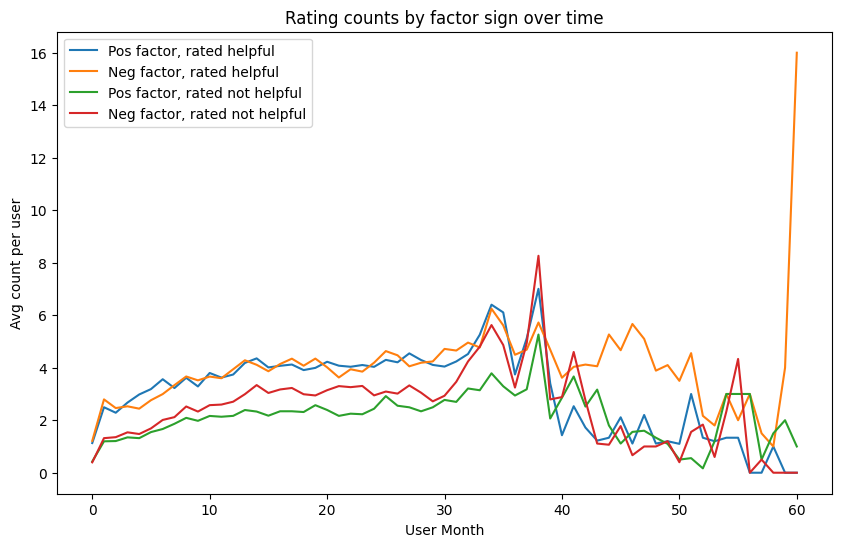

In [114]:
agg = ratings.groupby("userMonth")[[
    "posFactorRatedHelpful",
    "negFactorRatedHelpful",
    "posFactorRatedNotHelpful",
    "negFactorRatedNotHelpful"
]].mean()

plt.figure(figsize=(10,6))
plt.plot(agg.index, agg["posFactorRatedHelpful"], label="Pos factor, rated helpful")
plt.plot(agg.index, agg["negFactorRatedHelpful"], label="Neg factor, rated helpful")
plt.plot(agg.index, agg["posFactorRatedNotHelpful"], label="Pos factor, rated not helpful")
plt.plot(agg.index, agg["negFactorRatedNotHelpful"], label="Neg factor, rated not helpful")

plt.xlabel("User Month")
plt.ylabel("Avg count per user")
plt.title("Rating counts by factor sign over time")
plt.legend()
plt.show()

#### For raters, also consider the percent of ratings they gave that were correct, along with the average note intercept of notes they rated helpful and not helpful.

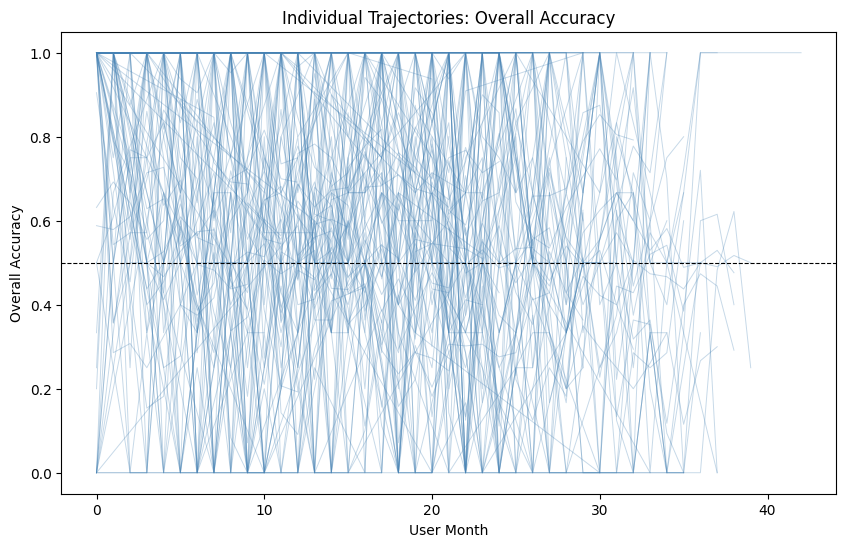

In [115]:
user_counts = ratings.groupby("raterParticipantId")["userMonth"].count()
eligible = user_counts[user_counts >= 10].index
sampled = np.random.default_rng(42).choice(eligible, size=min(100, len(eligible)), replace=False)
sample_df = ratings[ratings["raterParticipantId"].isin(sampled)]

plt.figure(figsize=(10, 6))

for uid, g in sample_df.groupby("raterParticipantId"):
    g = g.sort_values("userMonth")
    plt.plot(g["userMonth"], g["overallAccuracy"], alpha=0.3, linewidth=0.7, color="steelblue")

plt.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("User Month")
plt.ylabel("Overall Accuracy")
plt.title("Individual Trajectories: Overall Accuracy")
plt.show()

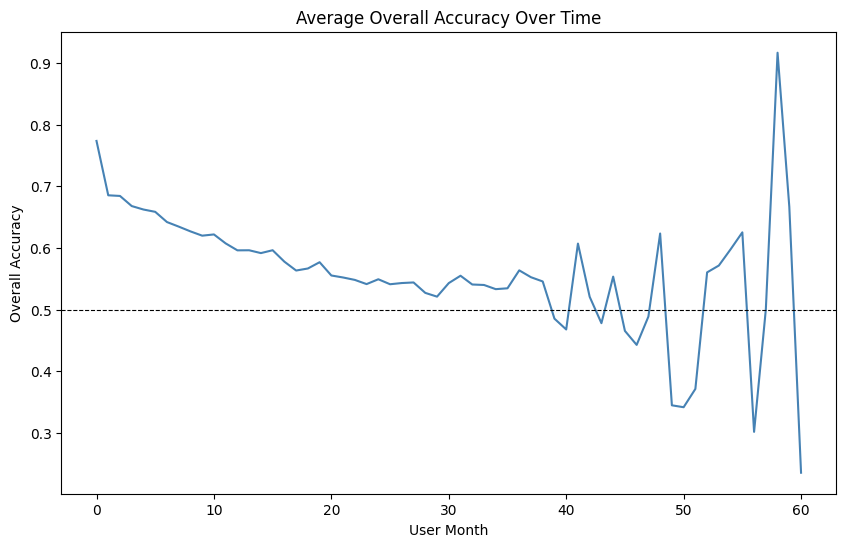

In [116]:
agg = ratings.groupby("userMonth")["overallAccuracy"].mean()

plt.figure(figsize=(10, 6))
plt.plot(agg.index, agg.values, color="steelblue")
plt.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("User Month")
plt.ylabel("Overall Accuracy")
plt.title("Average Overall Accuracy Over Time")
plt.show()

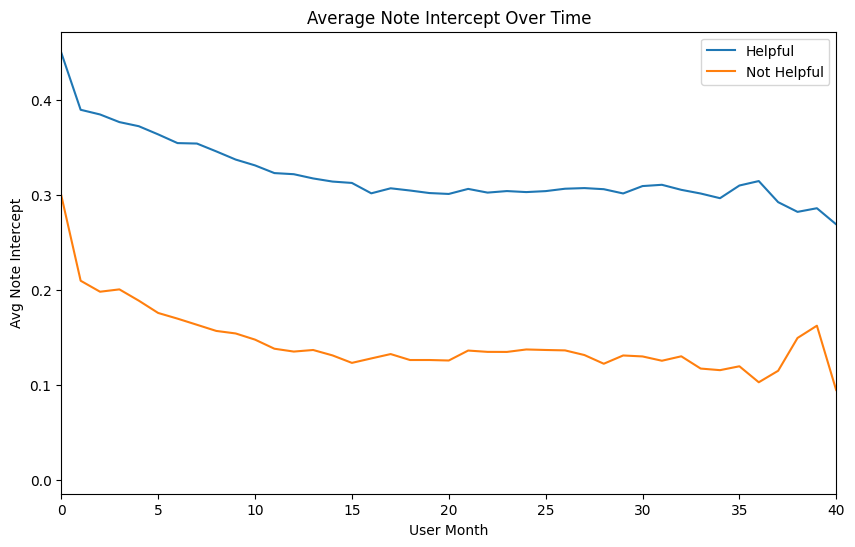

In [118]:
agg = ratings.groupby("userMonth")[["avgHelpfulIntercept", "avgNotHelpfulIntercept"]].mean()

plt.figure(figsize=(10, 6))
plt.plot(agg.index, agg["avgHelpfulIntercept"], label="Helpful")
plt.plot(agg.index, agg["avgNotHelpfulIntercept"], label="Not Helpful")
plt.xlabel("User Month")
plt.xlim(0, 40)
plt.ylabel("Avg Note Intercept")
plt.title("Average Note Intercept Over Time")
plt.legend()
plt.show()

#### For **writers**, consider the average note factor of notes the user wrote


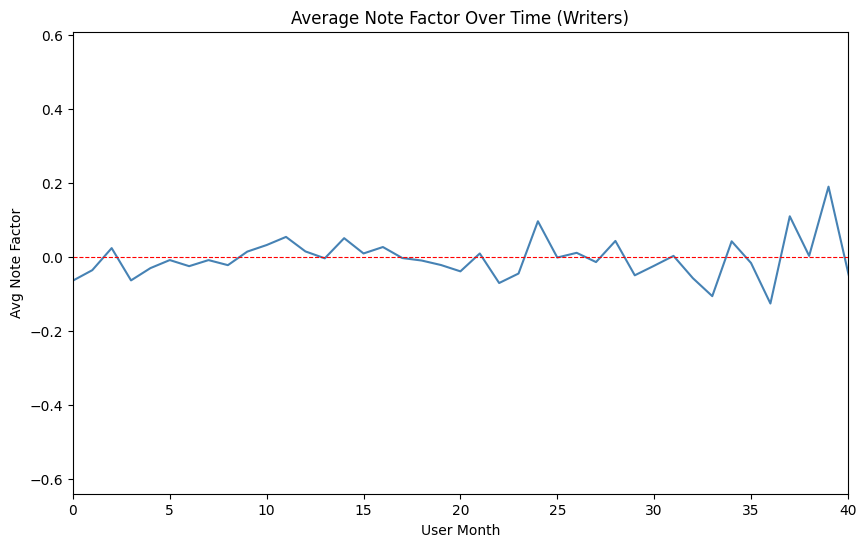

In [ ]:
agg = note.groupby("userMonth")["avgNoteFactor"].mean()

plt.figure(figsize=(10, 6))
plt.plot(agg.index, agg.values, color="steelblue")
plt.axhline(0, color="red", linewidth=0.8, linestyle="--")
plt.xlim(0, 40)
plt.xlabel("User Month")
plt.ylabel("Avg Note Factor")
plt.title("Average Note Factor Over Time (Writers)")
plt.show()

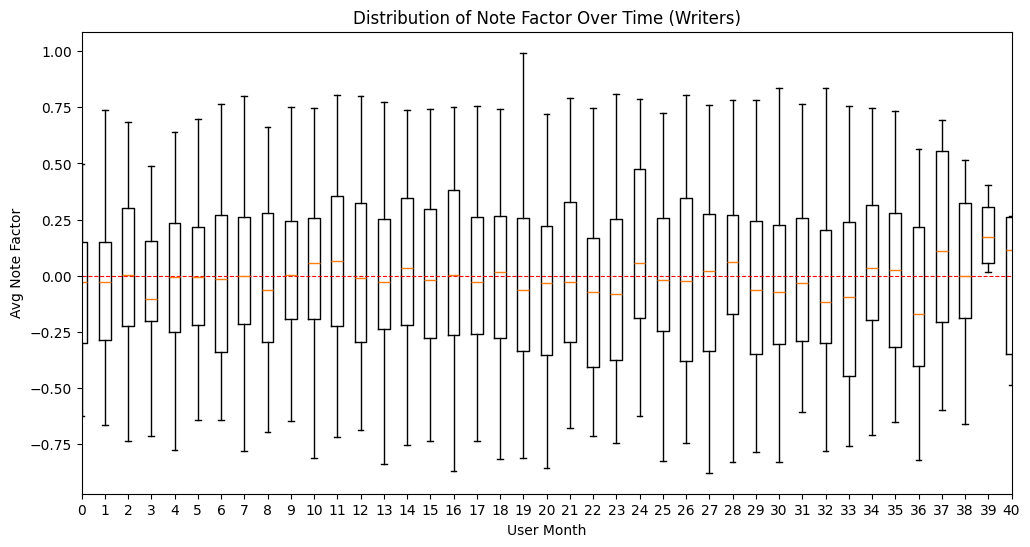

In [134]:
month_counts = note["userMonth"].value_counts()
valid_months = month_counts[month_counts > 2].index
plot_df = note[note["userMonth"].isin(valid_months)]
months_sorted = sorted(valid_months)

data = [plot_df[plot_df["userMonth"] == m]["avgNoteFactor"].dropna()
        for m in months_sorted]

plt.figure(figsize=(12, 6))

plt.boxplot(data, positions=months_sorted, showfliers=False)
plt.axhline(0, color="red", linewidth=0.8, linestyle="--")
plt.xlabel("User Month")
plt.xlim(0,40)
plt.ylabel("Avg Note Factor")
plt.title("Distribution of Note Factor Over Time (Writers)")
plt.show()

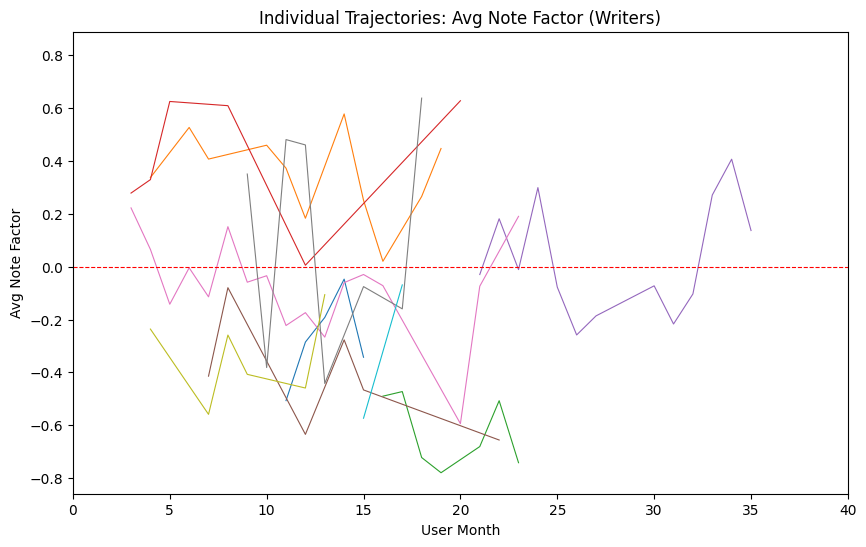

In [150]:
user_counts = note.groupby("noteAuthorParticipantId")["userMonth"].count()
eligible = user_counts[user_counts >= 6].index
sampled = np.random.default_rng(42).choice(eligible, size=min(10, len(eligible)), replace=False)
sample_df = note[note["noteAuthorParticipantId"].isin(sampled)]

plt.figure(figsize=(10, 6))

for uid, g in sample_df.groupby("noteAuthorParticipantId"):
    g = g.sort_values("userMonth")
    plt.plot(g["userMonth"], g["avgNoteFactor"], linewidth=0.8)

plt.axhline(0, color="red", linewidth=0.8, linestyle="--")
plt.xlim(0, 40)
plt.xlabel("User Month")
plt.ylabel("Avg Note Factor")
plt.title("Individual Trajectories: Avg Note Factor (Writers)")
plt.show()

#### For **writers**, also consider the average note intercept of notes they wrote, along with the number of CRH notes they wrote

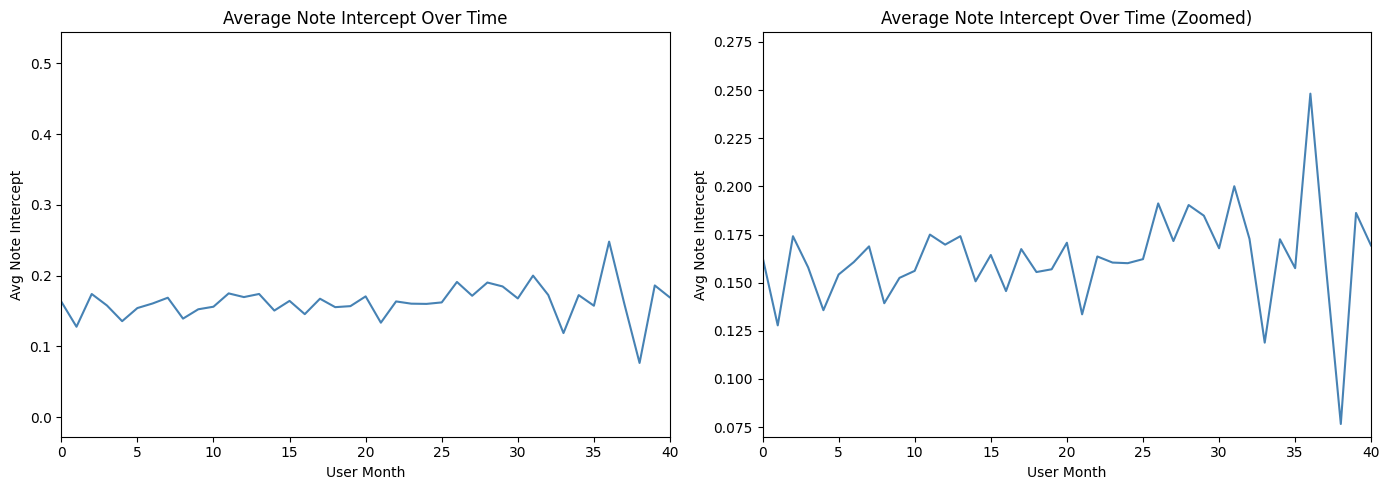

In [158]:
agg = note.groupby("userMonth")["avgNoteIntercept"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(agg.index, agg.values, color="steelblue")
axes[0].set_xlim(0, 40)
axes[0].set_xlabel("User Month")
axes[0].set_ylabel("Avg Note Intercept")
axes[0].set_title("Average Note Intercept Over Time")

axes[1].plot(agg.index, agg.values, color="steelblue")
axes[1].set_xlim(0, 40)
axes[1].set_ylim(0.07, 0.28)  # 여기 조절하면 돼
axes[1].set_xlabel("User Month")
axes[1].set_ylabel("Avg Note Intercept")
axes[1].set_title("Average Note Intercept Over Time (Zoomed)")

plt.tight_layout()
plt.show()

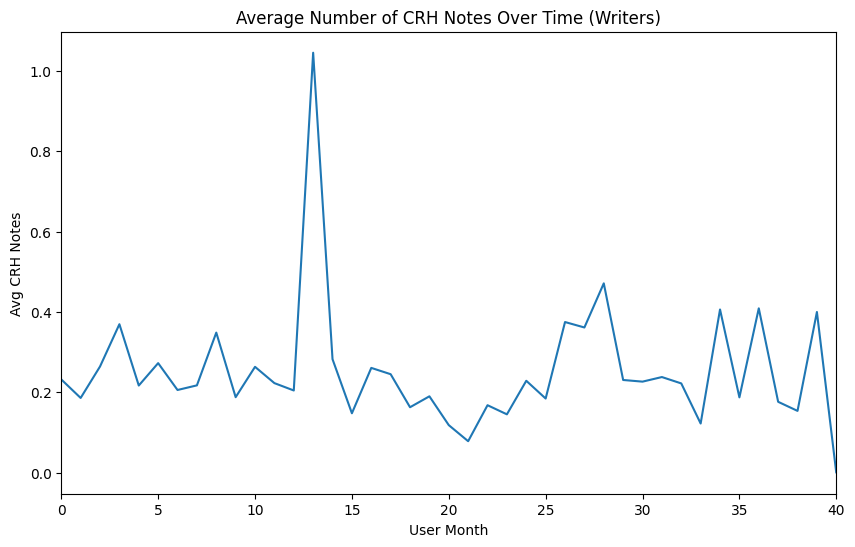

In [161]:
agg = note.groupby("userMonth")["hits"].mean()

plt.figure(figsize=(10, 6))
plt.plot(agg.index, agg.values)
plt.xlim(0, 40)
plt.xlabel("User Month")
plt.ylabel("Avg CRH Notes")
plt.title("Average Number of CRH Notes Over Time (Writers)")
plt.show()


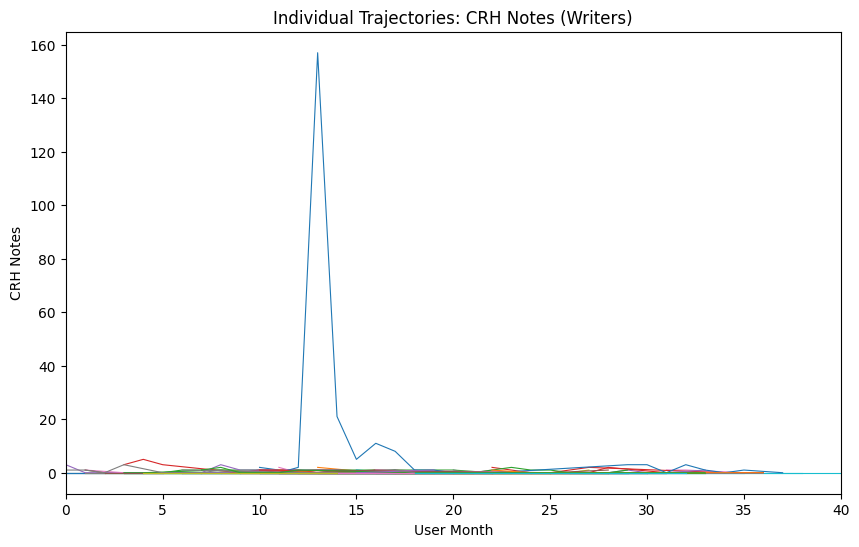

In [173]:
user_counts = note.groupby("noteAuthorParticipantId")["userMonth"].count()
eligible = user_counts[user_counts >= 2].index
sampled = np.random.default_rng(42).choice(eligible, size=min(100, len(eligible)), replace=False)
sample_df = note[note["noteAuthorParticipantId"].isin(sampled)]

plt.figure(figsize=(10, 6))

for uid, g in sample_df.groupby("noteAuthorParticipantId"):
    g = g.sort_values("userMonth")
    plt.plot(g["userMonth"], g["hits"], linewidth=0.8)

plt.xlim(0, 40)
plt.xlabel("User Month")
plt.ylabel("CRH Notes")
plt.title("Individual Trajectories: CRH Notes (Writers)")
plt.show()

In [180]:
sample_df.sort_values("hits", ascending=False).head(10)

,noteAuthorParticipantId,userMonth,sportsCount,diaries_&_daily_lifeCount,business_&_entrepreneursCount,science_&_technologyCount,news_&_social_concernCount,otherCount,calendarMonth,notesCreated,hitRate,hits,avgNoteFactor,avgNoteIntercept,topicsTargeted,avgRatingsEarned
3410,D16D3B645FC7BD9BD888BB950B98807A8CB2FCE06E0004...,13,0,0,1459,0,1,0,2024-01,1460,0.107534,157,-0.180954,0.283799,2,12.417123
3411,D16D3B645FC7BD9BD888BB950B98807A8CB2FCE06E0004...,14,0,0,313,3,0,1,2024-02,317,0.066246,21,-0.198352,0.272852,3,11.138801
3413,D16D3B645FC7BD9BD888BB950B98807A8CB2FCE06E0004...,16,0,0,27,0,0,1,2024-04,28,0.392857,11,-0.018503,0.366995,2,20.642857
3414,D16D3B645FC7BD9BD888BB950B98807A8CB2FCE06E0004...,17,0,0,72,0,0,28,2024-05,100,0.080000,8,-0.138754,0.270211,2,5.760000
3412,D16D3B645FC7BD9BD888BB950B98807A8CB2FCE06E0004...,15,0,0,49,0,1,0,2024-03,50,0.100000,5,-0.092544,0.253423,2,7.280000
2729,AA5783C76EC280E6E698AD562988641E6D3E9E67B4F56E...,4,0,0,0,1,35,0,2023-04,36,0.138889,5,0.347240,0.176331,2,54.305556
3420,D16D3B645FC7BD9BD888BB950B98807A8CB2FCE06E0004...,29,0,0,7,0,37,0,2025-05,44,0.081081,3,-0.237549,0.236914,2,12.704545
2517,9F347CA4F189D155AC2F9F58F9A269882EA01423B80CB8...,0,0,0,0,0,8,0,2023-01,8,0.375000,3,0.265914,0.340414,1,19.125000
3421,D16D3B645FC7BD9BD888BB950B98807A8CB2FCE06E0004...,30,0,0,32,0,18,0,2025-06,50,0.078947,3,-0.101566,0.271740,2,11.100000
3423,D16D3B645FC7BD9BD888BB950B98807A8CB2FCE06E0004...,32,0,0,26,0,10,0,2025-08,36,0.100000,3,-0.227671,0.239274,2,25.194444


#### For **requesters**, consider the number of requests they made that resulted in notes and CRH notes.

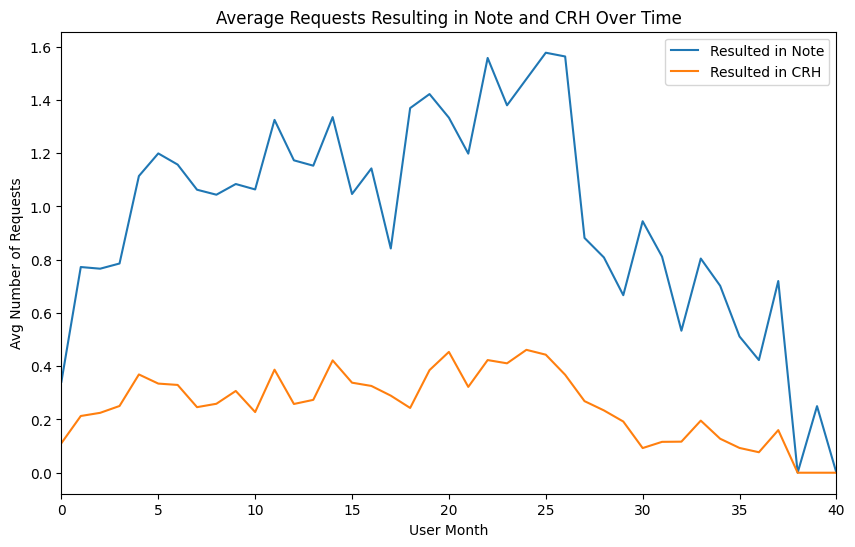

In [181]:
agg = request.groupby("userMonth")[["numRequestsResultingInNote", "numRequestsResultingInCrh"]].mean()

plt.figure(figsize=(10, 6))
plt.plot(agg.index, agg["numRequestsResultingInNote"], label="Resulted in Note")
plt.plot(agg.index, agg["numRequestsResultingInCrh"], label="Resulted in CRH")
plt.xlim(0, 40)
plt.xlabel("User Month")
plt.ylabel("Avg Number of Requests")
plt.title("Average Requests Resulting in Note and CRH Over Time")
plt.legend()
plt.show()